In [8]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

import wandb

/Users/triptibhardwaj/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [9]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [10]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

transform_original = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [11]:
full_dataset_original = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_original
)

full_dataset_augmented = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_augmented
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_val_transform
)

train_size = int(0.8 * len(full_dataset_original))   # 40000
val_size = len(full_dataset_original) - train_size   # 10000

train_dataset_original, val_dataset_original = random_split(
    full_dataset_original,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset_augmented, _ = random_split(
    full_dataset_augmented,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [12]:
batch_size = 128

train_loader_original = DataLoader(train_dataset_original, batch_size=batch_size, shuffle=True)
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset_original, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

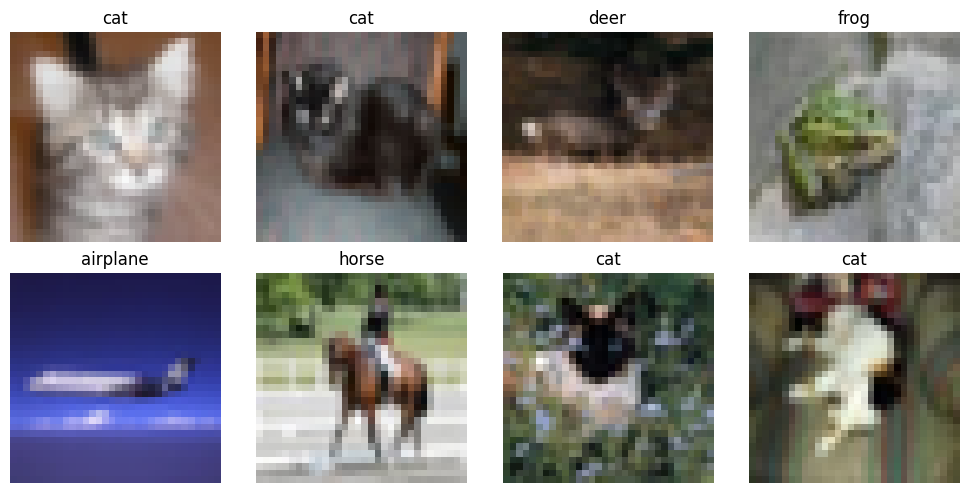

In [13]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

def imshow(img):
    img = img.permute(1, 2, 0).numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")

images, labels = next(iter(train_loader_original))

plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    plt.title(classes[labels[i]])
plt.tight_layout()
plt.show()

In [14]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)              
        x = x.flatten(2)              
        x = x.transpose(1, 2)        
        return x

In [15]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=128,
        depth=6,
        num_heads=4,
        mlp_dim=256,
        dropout=0.1
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed
        x = self.dropout(x)

        x = self.transformer(x)
        x = self.norm(x)

        cls_output = x[:, 0]
        logits = self.head(cls_output)
        return logits

In [16]:
def get_resnet18(num_classes=10):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [17]:
def get_cross_entropy_loss():
    return nn.CrossEntropyLoss()

def get_label_smoothing_loss(smoothing=0.1):
    return nn.CrossEntropyLoss(label_smoothing=smoothing)

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()
    
def get_loss_function(loss_name="cross_entropy"):
    if loss_name == "cross_entropy":
        return get_cross_entropy_loss()
    elif loss_name == "label_smoothing":
        return get_label_smoothing_loss()
    elif loss_name == "focal":
        return FocalLoss()
    else:
        raise ValueError("Invalid loss function name")
    
def get_optimizer(model, optimizer_name="adam", lr=1e-3):
    if optimizer_name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "adam":
        return optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("Invalid optimizer name")
    
def calculate_accuracy(outputs, labels):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

In [18]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=10):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_acc = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_acc += calculate_accuracy(outputs, labels) * images.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_acc = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_acc += calculate_accuracy(outputs, labels) * images.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    return history

In [19]:
def evaluate_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    test_acc = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            test_acc += calculate_accuracy(outputs, labels) * images.size(0)

    test_loss /= len(test_loader.dataset)
    test_acc /= len(test_loader.dataset)

    return test_loss, test_acc

In [20]:
def plot_history(history, title="Training History"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

Epoch 1: train_loss=1.7736, val_loss=1.5547, train_acc=0.3352, val_acc=0.4424
Epoch 2: train_loss=1.4114, val_loss=1.2883, train_acc=0.4824, val_acc=0.5340
Epoch 3: train_loss=1.2377, val_loss=1.1497, train_acc=0.5489, val_acc=0.5787
Epoch 4: train_loss=1.1240, val_loss=1.0892, train_acc=0.5929, val_acc=0.6098
Epoch 5: train_loss=1.0507, val_loss=1.0331, train_acc=0.6199, val_acc=0.6328
Epoch 6: train_loss=0.9812, val_loss=0.9788, train_acc=0.6486, val_acc=0.6491
Epoch 7: train_loss=0.9338, val_loss=0.9699, train_acc=0.6653, val_acc=0.6589
Epoch 8: train_loss=0.8914, val_loss=0.9543, train_acc=0.6786, val_acc=0.6599
Epoch 9: train_loss=0.8457, val_loss=0.8880, train_acc=0.6964, val_acc=0.6915
Epoch 10: train_loss=0.8222, val_loss=0.8867, train_acc=0.7076, val_acc=0.6941


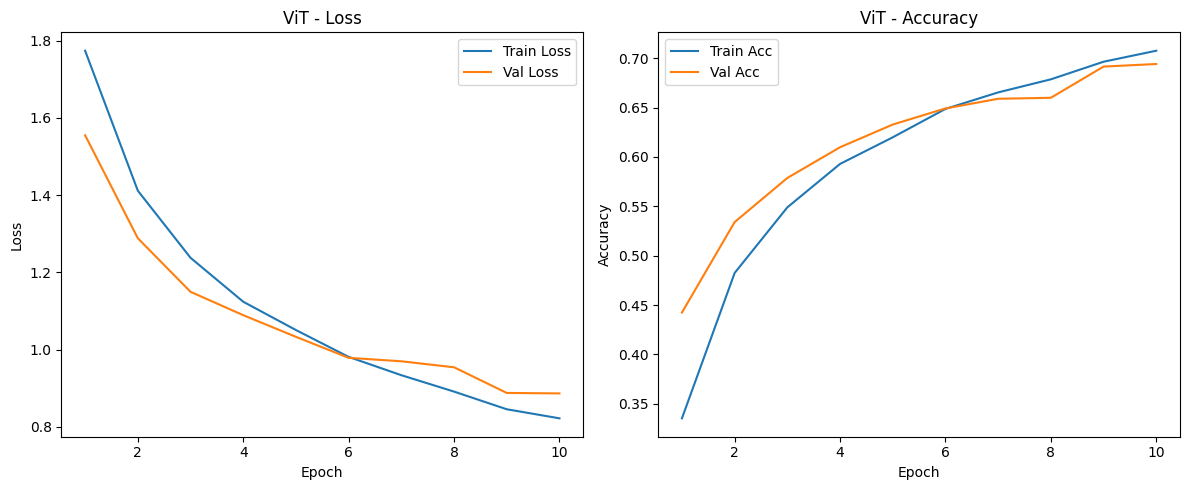

In [16]:
vit_model = VisionTransformer(
    img_size=32,
    patch_size=4,
    embed_dim=128,
    depth=6,
    num_heads=4,
    mlp_dim=256,
    num_classes=10
)

criterion = get_loss_function("cross_entropy")
optimizer = get_optimizer(vit_model, "adam", lr=1e-3)

vit_history = train_model(
    vit_model,
    train_loader_original,
    val_loader,
    optimizer,
    criterion,
    epochs=10
)

plot_history(vit_history, title="ViT")

Epoch 1: train_loss=1.4256, val_loss=1.2504, train_acc=0.4853, val_acc=0.5540
Epoch 2: train_loss=1.0258, val_loss=1.1015, train_acc=0.6369, val_acc=0.6203
Epoch 3: train_loss=0.8418, val_loss=0.9333, train_acc=0.7023, val_acc=0.6724
Epoch 4: train_loss=0.7078, val_loss=0.9439, train_acc=0.7498, val_acc=0.6848
Epoch 5: train_loss=0.5941, val_loss=0.9438, train_acc=0.7919, val_acc=0.6828
Epoch 6: train_loss=0.5005, val_loss=0.8235, train_acc=0.8222, val_acc=0.7257
Epoch 7: train_loss=0.4070, val_loss=0.9144, train_acc=0.8570, val_acc=0.7173
Epoch 8: train_loss=0.3351, val_loss=0.8802, train_acc=0.8816, val_acc=0.7364
Epoch 9: train_loss=0.2693, val_loss=1.0076, train_acc=0.9051, val_acc=0.7257
Epoch 10: train_loss=0.2129, val_loss=0.9734, train_acc=0.9249, val_acc=0.7343


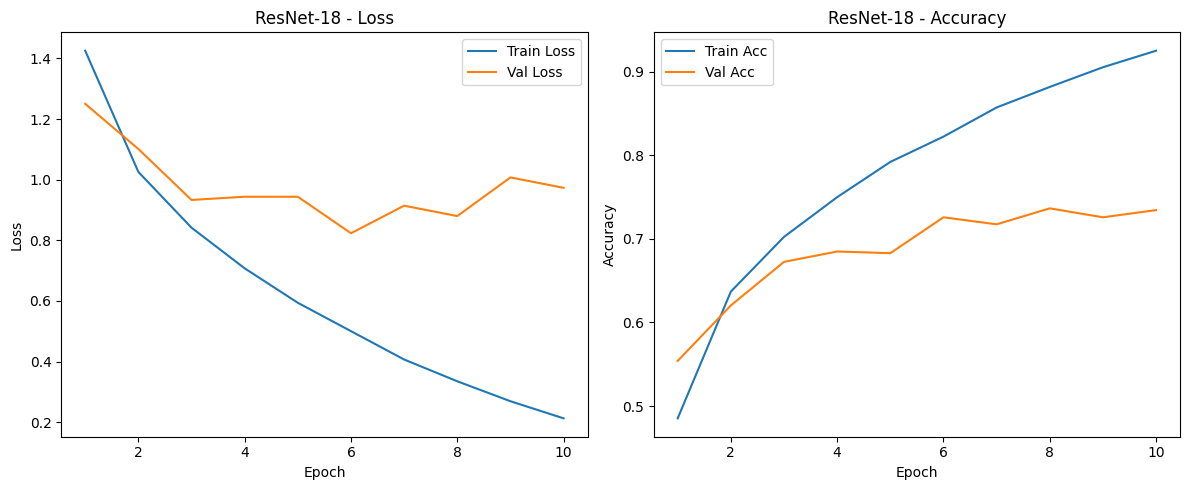

In [17]:
resnet_model = get_resnet18(num_classes=10)

criterion = get_loss_function("cross_entropy")
optimizer = get_optimizer(resnet_model, "adam", lr=1e-3)

resnet_history = train_model(
    resnet_model,
    train_loader_original,
    val_loader,
    optimizer,
    criterion,
    epochs=10
)

plot_history(resnet_history, title="ResNet-18")

In [18]:
vit_test_loss, vit_test_acc = evaluate_model(vit_model, test_loader, criterion)
resnet_test_loss, resnet_test_acc = evaluate_model(resnet_model, test_loader, criterion)

print("ViT Test Loss:", vit_test_loss)
print("ViT Test Accuracy:", vit_test_acc)

print("ResNet-18 Test Loss:", resnet_test_loss)
print("ResNet-18 Test Accuracy:", resnet_test_acc)

ViT Test Loss: 0.9002072985649109
ViT Test Accuracy: 0.6842
ResNet-18 Test Loss: 1.0045636777162552
ResNet-18 Test Accuracy: 0.7328


In [19]:
model_types = ["vit", "resnet18"]
dataset_types = ["original", "augmented"]
loss_functions = ["cross_entropy", "label_smoothing", "focal"]
optimizers_list = ["sgd", "rmsprop", "adam"]

results = []

for model_type in model_types:
    for dataset_type in dataset_types:
        for loss_name in loss_functions:
            for opt_name in optimizers_list:
                print(f"\nRunning: {model_type}, {dataset_type}, {loss_name}, {opt_name}")

                if model_type == "vit":
                    model = VisionTransformer(
                        img_size=32,
                        patch_size=4,
                        embed_dim=128,
                        depth=6,
                        num_heads=4,
                        mlp_dim=256,
                        num_classes=10
                    )
                else:
                    model = get_resnet18(num_classes=10)

                train_loader = train_loader_original if dataset_type == "original" else train_loader_augmented
                criterion = get_loss_function(loss_name)
                optimizer = get_optimizer(model, opt_name, lr=1e-3)

                start_time = time.time()

                history = train_model(
                    model,
                    train_loader,
                    val_loader,
                    optimizer,
                    criterion,
                    epochs=5
                )

                training_time = time.time() - start_time
                test_loss, test_acc = evaluate_model(model, test_loader, criterion)

                results.append({
                    "model": model_type,
                    "dataset": dataset_type,
                    "loss_function": loss_name,
                    "optimizer": opt_name,
                    "test_loss": test_loss,
                    "test_accuracy": test_acc,
                    "training_time_sec": training_time
                })
                


Running: vit, original, cross_entropy, sgd
Epoch 1: train_loss=2.0314, val_loss=1.9425, train_acc=0.2438, val_acc=0.2794
Epoch 2: train_loss=1.9119, val_loss=1.8420, train_acc=0.2952, val_acc=0.3200
Epoch 3: train_loss=1.8067, val_loss=1.7305, train_acc=0.3335, val_acc=0.3547
Epoch 4: train_loss=1.7263, val_loss=1.6716, train_acc=0.3615, val_acc=0.3871
Epoch 5: train_loss=1.6808, val_loss=1.6475, train_acc=0.3771, val_acc=0.3980

Running: vit, original, cross_entropy, rmsprop
Epoch 1: train_loss=2.2878, val_loss=2.3253, train_acc=0.1330, val_acc=0.0973
Epoch 2: train_loss=2.2892, val_loss=2.2219, train_acc=0.1176, val_acc=0.1594
Epoch 3: train_loss=2.2639, val_loss=2.2596, train_acc=0.1336, val_acc=0.1188
Epoch 4: train_loss=2.2820, val_loss=2.3078, train_acc=0.1197, val_acc=0.1001
Epoch 5: train_loss=2.3060, val_loss=2.3096, train_acc=0.1018, val_acc=0.0973

Running: vit, original, cross_entropy, adam
Epoch 1: train_loss=1.7997, val_loss=1.5411, train_acc=0.3246, val_acc=0.4371
Epoch

In [20]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("vit_resnet_results.csv", index=False)

       model    dataset    loss_function optimizer  test_loss  test_accuracy  \
0        vit   original    cross_entropy       sgd   1.657954         0.3908   
1        vit   original    cross_entropy   rmsprop   2.308148         0.1000   
2        vit   original    cross_entropy      adam   0.995844         0.6418   
3        vit   original  label_smoothing       sgd   1.815864         0.3822   
4        vit   original  label_smoothing   rmsprop   2.221382         0.1475   
5        vit   original  label_smoothing      adam   1.254655         0.6585   
6        vit   original            focal       sgd   1.119430         0.4021   
7        vit   original            focal   rmsprop   1.868292         0.1000   
8        vit   original            focal      adam   0.612051         0.6299   
9        vit  augmented    cross_entropy       sgd   1.675989         0.3825   
10       vit  augmented    cross_entropy   rmsprop   2.305429         0.1000   
11       vit  augmented    cross_entropy

In [21]:
torch.save(vit_model.state_dict(), "vit_model.pth")
torch.save(resnet_model.state_dict(), "resnet18_model.pth")

In [22]:
from huggingface_hub import create_repo, upload_file

create_repo("dl_lab10", private=False, exist_ok=True)

upload_file(
    path_or_fileobj="vit_model.pth",
    path_in_repo="vit_model.pth",
    repo_id="triptibhardwaj/dl_lab10"
)

upload_file(
    path_or_fileobj="resnet18_model.pth",
    path_in_repo="resnet18_model.pth",
    repo_id="triptibhardwaj/dl_lab10"
)

Processing Files (1 / 1): 100%|██████████| 3.27MB / 3.27MB,  431kB/s  
New Data Upload: 100%|██████████| 3.27MB / 3.27MB,  431kB/s  
Processing Files (1 / 1): 100%|██████████| 44.8MB / 44.8MB, 20.4MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


CommitInfo(commit_url='https://huggingface.co/triptibhardwaj/dl_lab10/commit/d373029a985128e1fce4baf97dede78be91bc318', commit_message='Upload resnet18_model.pth with huggingface_hub', commit_description='', oid='d373029a985128e1fce4baf97dede78be91bc318', pr_url=None, repo_url=RepoUrl('https://huggingface.co/triptibhardwaj/dl_lab10', endpoint='https://huggingface.co', repo_type='model', repo_id='triptibhardwaj/dl_lab10'), pr_revision=None, pr_num=None)

In [22]:
def train_classifier_wandb(model, train_loader, val_loader, optimizer, criterion, config):

    wandb.init(
        entity="triptibhardwaj_25afi04",
        project="cifar10-vit-resnet",
        config=config
    )

    epochs = config["epochs"]

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_acc = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_acc += calculate_accuracy(outputs, labels) * images.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_acc = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_acc += calculate_accuracy(outputs, labels) * images.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc /= len(val_loader.dataset)

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "lr": optimizer.param_groups[0]["lr"]
        })

        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    wandb.finish()

In [ ]:
# model_types = ["vit", "resnet18"]
# dataset_types = ["original", "augmented"]
# loss_functions = ["cross_entropy", "label_smoothing", "focal"]
# optimizers_list = ["sgd", "rmsprop", "adam"]

# for model_type in model_types:
#     for dataset_type in dataset_types:
#         for loss_name in loss_functions:
#             for opt_name in optimizers_list:
#                 if model_type == "vit":
#                     model = VisionTransformer(
#                         img_size=32,
#                         patch_size=4,
#                         embed_dim=128,
#                         depth=6,
#                         num_heads=4,
#                         mlp_dim=256,
#                         num_classes=10
#                     ).to(device)
#                 else:
#                     model = get_resnet18(num_classes=10).to(device)

#                 train_loader = train_loader_original if dataset_type == "original" else train_loader_augmented
#                 criterion = get_loss_function(loss_name)
#                 optimizer = get_optimizer(model, opt_name, lr=1e-3)

#                 config = {
#                     "model": model_type,
#                     "dataset": dataset_type,
#                     "loss_function": loss_name,
#                     "optimizer": opt_name,
#                     "epochs": 5,
#                     "lr": 1e-3
#                 }

#                 train_classifier_wandb(
#                     model=model,
#                     train_loader=train_loader,
#                     val_loader=val_loader,
#                     optimizer=optimizer,
#                     criterion=criterion,
#                     config=config
#                 )

Epoch 1: train_loss=2.0198, val_loss=1.9321, train_acc=0.2510, val_acc=0.2874
Epoch 2: train_loss=1.9118, val_loss=1.8506, train_acc=0.2948, val_acc=0.3242
Epoch 3: train_loss=1.8281, val_loss=1.7538, train_acc=0.3246, val_acc=0.3540
Epoch 4: train_loss=1.7468, val_loss=1.6796, train_acc=0.3522, val_acc=0.3822
Epoch 5: train_loss=1.6944, val_loss=1.6462, train_acc=0.3730, val_acc=0.3952


epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_accuracy,▁▄▅▇█
train_loss,█▆▄▂▁
val_accuracy,▁▃▅▇█
val_loss,█▆▄▂▁
epoch,5
lr,0.001
train_accuracy,0.373
train_loss,1.69436
val_accuracy,0.3952


Epoch 1: train_loss=2.3276, val_loss=2.2941, train_acc=0.1108, val_acc=0.1213
Epoch 2: train_loss=2.2226, val_loss=2.1677, train_acc=0.1682, val_acc=0.1860
Epoch 3: train_loss=2.2253, val_loss=2.2572, train_acc=0.1638, val_acc=0.1428
Epoch 4: train_loss=2.2614, val_loss=2.2575, train_acc=0.1411, val_acc=0.1458
Epoch 5: train_loss=2.2588, val_loss=2.2487, train_acc=0.1426, val_acc=0.1525


epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_accuracy,▁█▇▅▅
train_loss,█▁▁▄▃
val_accuracy,▁█▃▄▄
val_loss,█▁▆▆▅
epoch,5
lr,0.001
train_accuracy,0.14255
train_loss,2.25884
val_accuracy,0.1525


Epoch 1: train_loss=1.7658, val_loss=1.5419, train_acc=0.3358, val_acc=0.4196
Epoch 2: train_loss=1.3967, val_loss=1.2838, train_acc=0.4895, val_acc=0.5453
Epoch 3: train_loss=1.2093, val_loss=1.1303, train_acc=0.5627, val_acc=0.5937
Epoch 4: train_loss=1.0886, val_loss=1.0775, train_acc=0.6091, val_acc=0.6147
Epoch 5: train_loss=1.0044, val_loss=1.0075, train_acc=0.6402, val_acc=0.6417


...

Epoch 1: train_loss=1.9702, val_loss=1.8025, train_acc=0.3134, val_acc=0.3893
Epoch 2: train_loss=1.7275, val_loss=1.6889, train_acc=0.4264, val_acc=0.4508
Epoch 3: train_loss=1.6313, val_loss=1.6323, train_acc=0.4771, val_acc=0.4791
Epoch 4: train_loss=1.5639, val_loss=1.5848, train_acc=0.5108, val_acc=0.4969
Epoch 5: train_loss=1.5079, val_loss=1.5339, train_acc=0.5376, val_acc=0.5278


epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_accuracy,▁▅▆▇█
train_loss,█▄▃▂▁
val_accuracy,▁▄▆▆█
val_loss,█▅▄▂▁
epoch,5
lr,0.001
train_accuracy,0.5376
train_loss,1.50787
val_accuracy,0.5278


Epoch 1: train_loss=1.8468, val_loss=1.7301, train_acc=0.3862, val_acc=0.4274
Epoch 2: train_loss=1.5440, val_loss=1.8011, train_acc=0.5212, val_acc=0.4324
Epoch 3: train_loss=1.3948, val_loss=1.6642, train_acc=0.5938, val_acc=0.5113
Epoch 4: train_loss=1.3004, val_loss=1.5877, train_acc=0.6386, val_acc=0.5645
Epoch 5: train_loss=1.2354, val_loss=1.3257, train_acc=0.6696, val_acc=0.6345


epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_accuracy,▁▄▆▇█
train_loss,█▅▃▂▁
val_accuracy,▁▁▄▆█
val_loss,▇█▆▅▁
epoch,5
lr,0.001
train_accuracy,0.6696
train_loss,1.23541
val_accuracy,0.6345


Epoch 1: train_loss=1.7445, val_loss=1.6493, train_acc=0.4206, val_acc=0.4714
Epoch 2: train_loss=1.4813, val_loss=1.5943, train_acc=0.5483, val_acc=0.5159


In [23]:
all_configs = []

model_types = ["vit", "resnet18"]
dataset_types = ["original", "augmented"]
loss_functions = ["cross_entropy", "label_smoothing", "focal"]
optimizers_list = ["sgd", "rmsprop", "adam"]

for model_type in model_types:
    for dataset_type in dataset_types:
        for loss_name in loss_functions:
            for opt_name in optimizers_list:
                all_configs.append((model_type, dataset_type, loss_name, opt_name))

start_index = 31

for idx in range(start_index, len(all_configs)):
    model_type, dataset_type, loss_name, opt_name = all_configs[idx]

    print(f"Running model {idx+1}/36: {model_type}, {dataset_type}, {loss_name}, {opt_name}")

    if model_type == "vit":
        model = VisionTransformer(
            img_size=32,
            patch_size=4,
            embed_dim=128,
            depth=6,
            num_heads=4,
            mlp_dim=256,
            num_classes=10
        ).to(device)
    else:
        model = get_resnet18(num_classes=10).to(device)

    train_loader = train_loader_original if dataset_type == "original" else train_loader_augmented
    criterion = get_loss_function(loss_name)
    optimizer = get_optimizer(model, opt_name, lr=1e-3)

    config = {
        "model": model_type,
        "dataset": dataset_type,
        "loss_function": loss_name,
        "optimizer": opt_name,
        "epochs": 5,
        "lr": 1e-3,
        "run_number": idx + 1
    }

    train_classifier_wandb(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        config=config
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/triptibhardwaj/.netrc.


Running model 32/36: resnet18, augmented, label_smoothing, rmsprop


wandb: Currently logged in as: tripti-bhardwaj (triptibhardwaj_25afi04) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1: train_loss=1.8603, val_loss=2.0442, train_acc=0.3781, val_acc=0.3357
Epoch 2: train_loss=1.5468, val_loss=1.7123, train_acc=0.5204, val_acc=0.4950
Epoch 3: train_loss=1.4059, val_loss=1.6068, train_acc=0.5895, val_acc=0.5147
Epoch 4: train_loss=1.3080, val_loss=1.7347, train_acc=0.6343, val_acc=0.5760


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

Running model 36/36: resnet18, augmented, focal, adam


Epoch 1: train_loss=1.1081, val_loss=0.9341, train_acc=0.4050, val_acc=0.4888
Epoch 2: train_loss=0.8078, val_loss=0.7655, train_acc=0.5283, val_acc=0.5608
Epoch 3: train_loss=0.6922, val_loss=0.6959, train_acc=0.5877, val_acc=0.5843
Epoch 4: train_loss=0.6159, val_loss=0.6468, train_acc=0.6243, val_acc=0.6175


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 5: train_loss=0.5687, val_loss=0.5902, train_acc=0.6494, val_acc=0.6459


epoch,▁▃▅▆█
lr,▁▁▁▁▁
train_accuracy,▁▅▆▇█
train_loss,█▄▃▂▁
val_accuracy,▁▄▅▇█
val_loss,█▅▃▂▁
epoch,5
lr,0.001
train_accuracy,0.64943
train_loss,0.56868
val_accuracy,0.6459
